# Heart Disease Prediction using Machine Learning
## Objective
> Explore the dataset: covering patterns
> conduct Extensive Exploratory Data Analysis
 >Preprocessing :
   * Remove irrelevent feature
   * Address missing values
   * treat outliers
   * Encodecategorical variable
   * Transform skewed feature to achive normal-like distribitation
> Model Building
   * Establish pipline for model that require scaling
   * Impliment and turn classification including KNN, Decision Tree and Random Forest
   * emphasize achiveing high recall for class 1 ensuring comprehebsive identification f hart patientd
> Evaluate and compare Model performance

This notebook performs data exploration, preprocessing, model training (Logistic Regression & Decision Tree), and evaluation.

## Importing libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold,GridSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier


## Loding Dataset

In [3]:
# Load dataset
df = pd.read_csv("heart_disease_uci.csv")

# Display first 5 rows
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
# Dataset Info
df.info()

# Statistical Summary
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
# Check missing values
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [6]:
# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_6288\4289966684.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_6288\4289966684.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode()[0], inplace=

In [7]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [8]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [9]:
# cnverting 4 unique values of target into 2 values
df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
df = df.drop('num',axis = 1)
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [10]:
# defining the continuous feature
continuous_feature = ['age','trestbps','thalch','oldpeak','ca','chol']

# Identify the feature to be converted to object data type
feature_to_convert = [feature for feature in df.columns if feature not in continuous_feature]

# convert theb identified feature to object data type
df[feature_to_convert] = df[feature_to_convert].astype('object')



In [11]:

# Statistical Summary
df.describe().T



,count,mean,std,min,25%,50%,75%,max
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.0,77.0
trestbps,920.0,131.995652,18.451300,0.0,120.00,130.0,140.0,200.0
chol,920.0,199.908696,109.040171,0.0,177.75,223.0,267.0,603.0
thalch,920.0,137.692391,25.145235,60.0,120.00,140.0,156.0,202.0
oldpeak,920.0,0.853261,1.058049,-2.6,0.00,0.5,1.5,6.2
ca,920.0,0.227174,0.628936,0.0,0.00,0.0,0.0,3.0


## Categorical Feature
  * sex: male = 1 and female = 0
  * cp : four unique types 0 = asymptomatic , 1 = atypical anginal, 2 = non anginal, 3 = typical anginal
  * fbs: two types true = 1 and False = 0
  * exang: = two unique types True = 1 and False =0
  * slope: three unique types downslopin = 0 flat = 1 upsloping = 2
  * thal: Three unique types: fixed defect = 0, normal = 1,  reversable defect = 2
  * target or num: two unique types: 1 = heart Diseasee and 0 = NO Heart Disease 

In [12]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,0,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,1,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,1
2,2,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,3,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,4,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


## EDA
### Univereant Analysis
### Numarical Variable Univariante Analysis

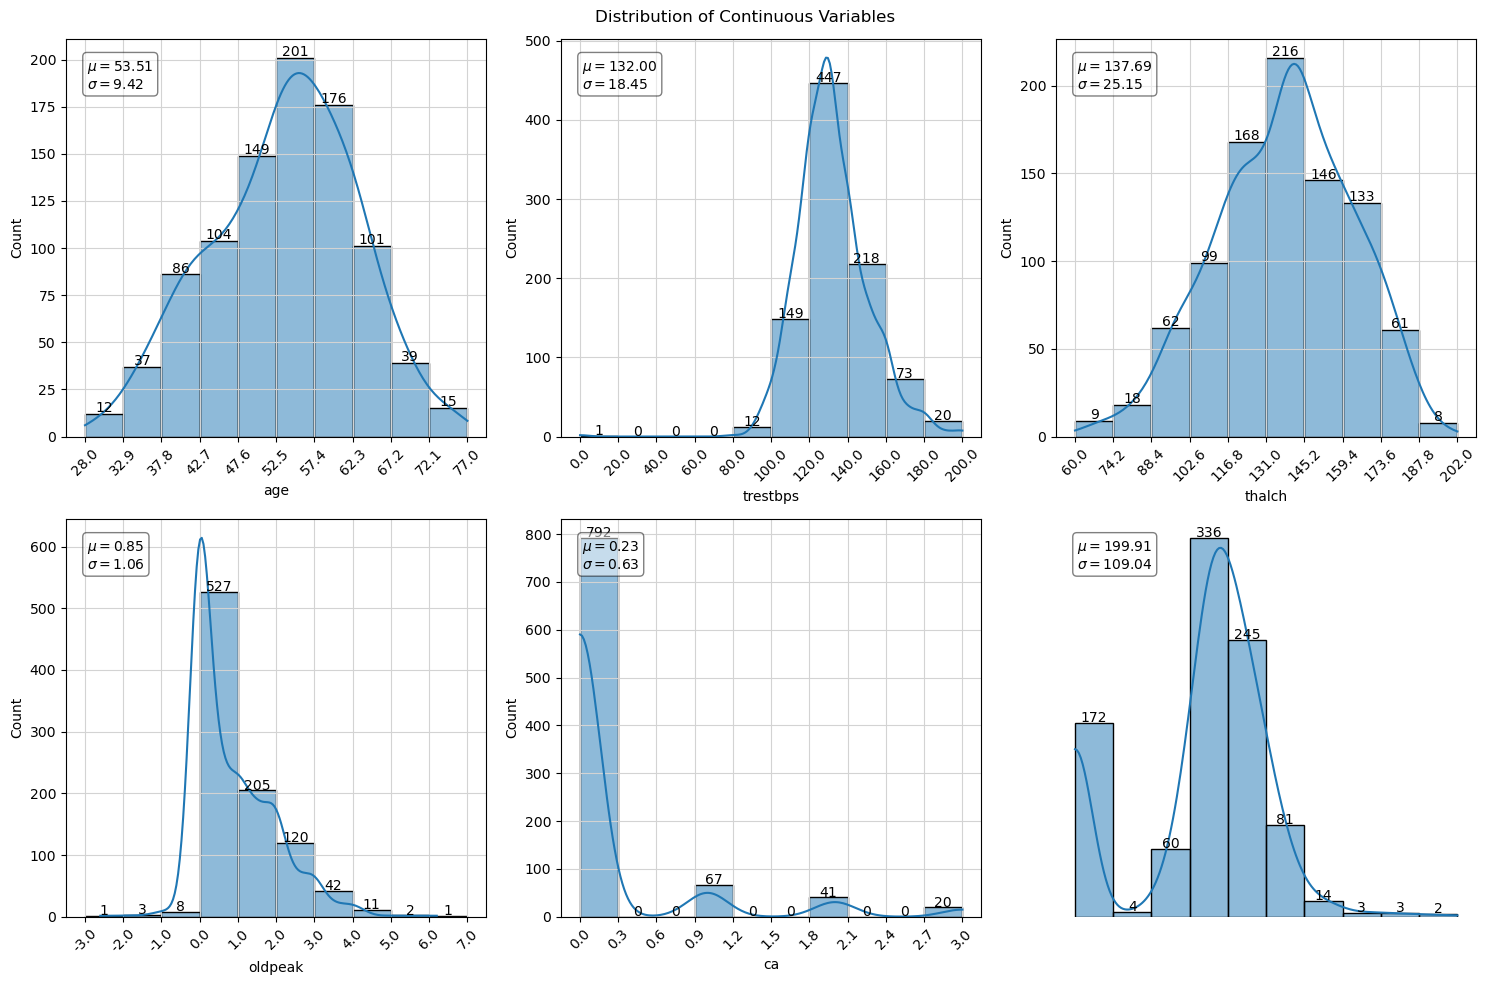

In [13]:
# filter out continuous feature for the univariate analysis
df_continuous = df[continuous_feature]

# set up the subplot
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15,10))

# loop to plot histogram for each continuous feature
for i, col in enumerate(df_continuous):

    x = i // 3
    y = i % 3

    values, bin_edges = np.histogram(
        df_continuous[col],
        range=(np.floor(df_continuous[col].min()),
               np.ceil(df_continuous[col].max()))
    )

    graph = sns.histplot(data=df_continuous, x=col, bins=bin_edges, kde=True, ax=ax[x,y])

    ax[x,y].set_xlabel(col)
    ax[x,y].set_ylabel('Count')

    ax[x,y].set_xticks(np.round(bin_edges,1))
    ax[x,y].set_xticklabels(np.round(bin_edges,1), rotation=45)

    ax[x,y].grid(color='lightgray')

    # annotate bars
    for p in graph.patches:
        ax[x,y].annotate(
            '{}'.format(int(p.get_height())),
            (p.get_x() + p.get_width()/2, p.get_height()+1),
            ha='center',
            fontsize=10
        )

    # mean and std text
    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))

    ax[x,y].text(0.05, 0.95, textstr,
                 transform=ax[x,y].transAxes,
                 fontsize=10,
                 verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax[1,2].axis('off')

plt.suptitle('Distribution of Continuous Variables')
plt.tight_layout()
plt.show()

## Inference
* Age: Data is evenly Distributed: the mean age of is about 52.5
* Trest BPS; BPS is between 120 to 140 for most of the persons
* Thalch: It is evenly distributed and mean is about 137.69
* Oldeak: the data is slightly skweed , and mean value is 0.853261
* CA: the data is not uniform, there are some up and down and mean is 0.227174
* Chol: the data is slightly Skweed

## Categorical Variable Univariate Analysis

In [14]:
# filter out categorical feature 
categorical_feature = df.columns.difference(continuous_feature)
df_categorical = df[categorical_feature]

categorical_feature = categorical_feature.drop('id')

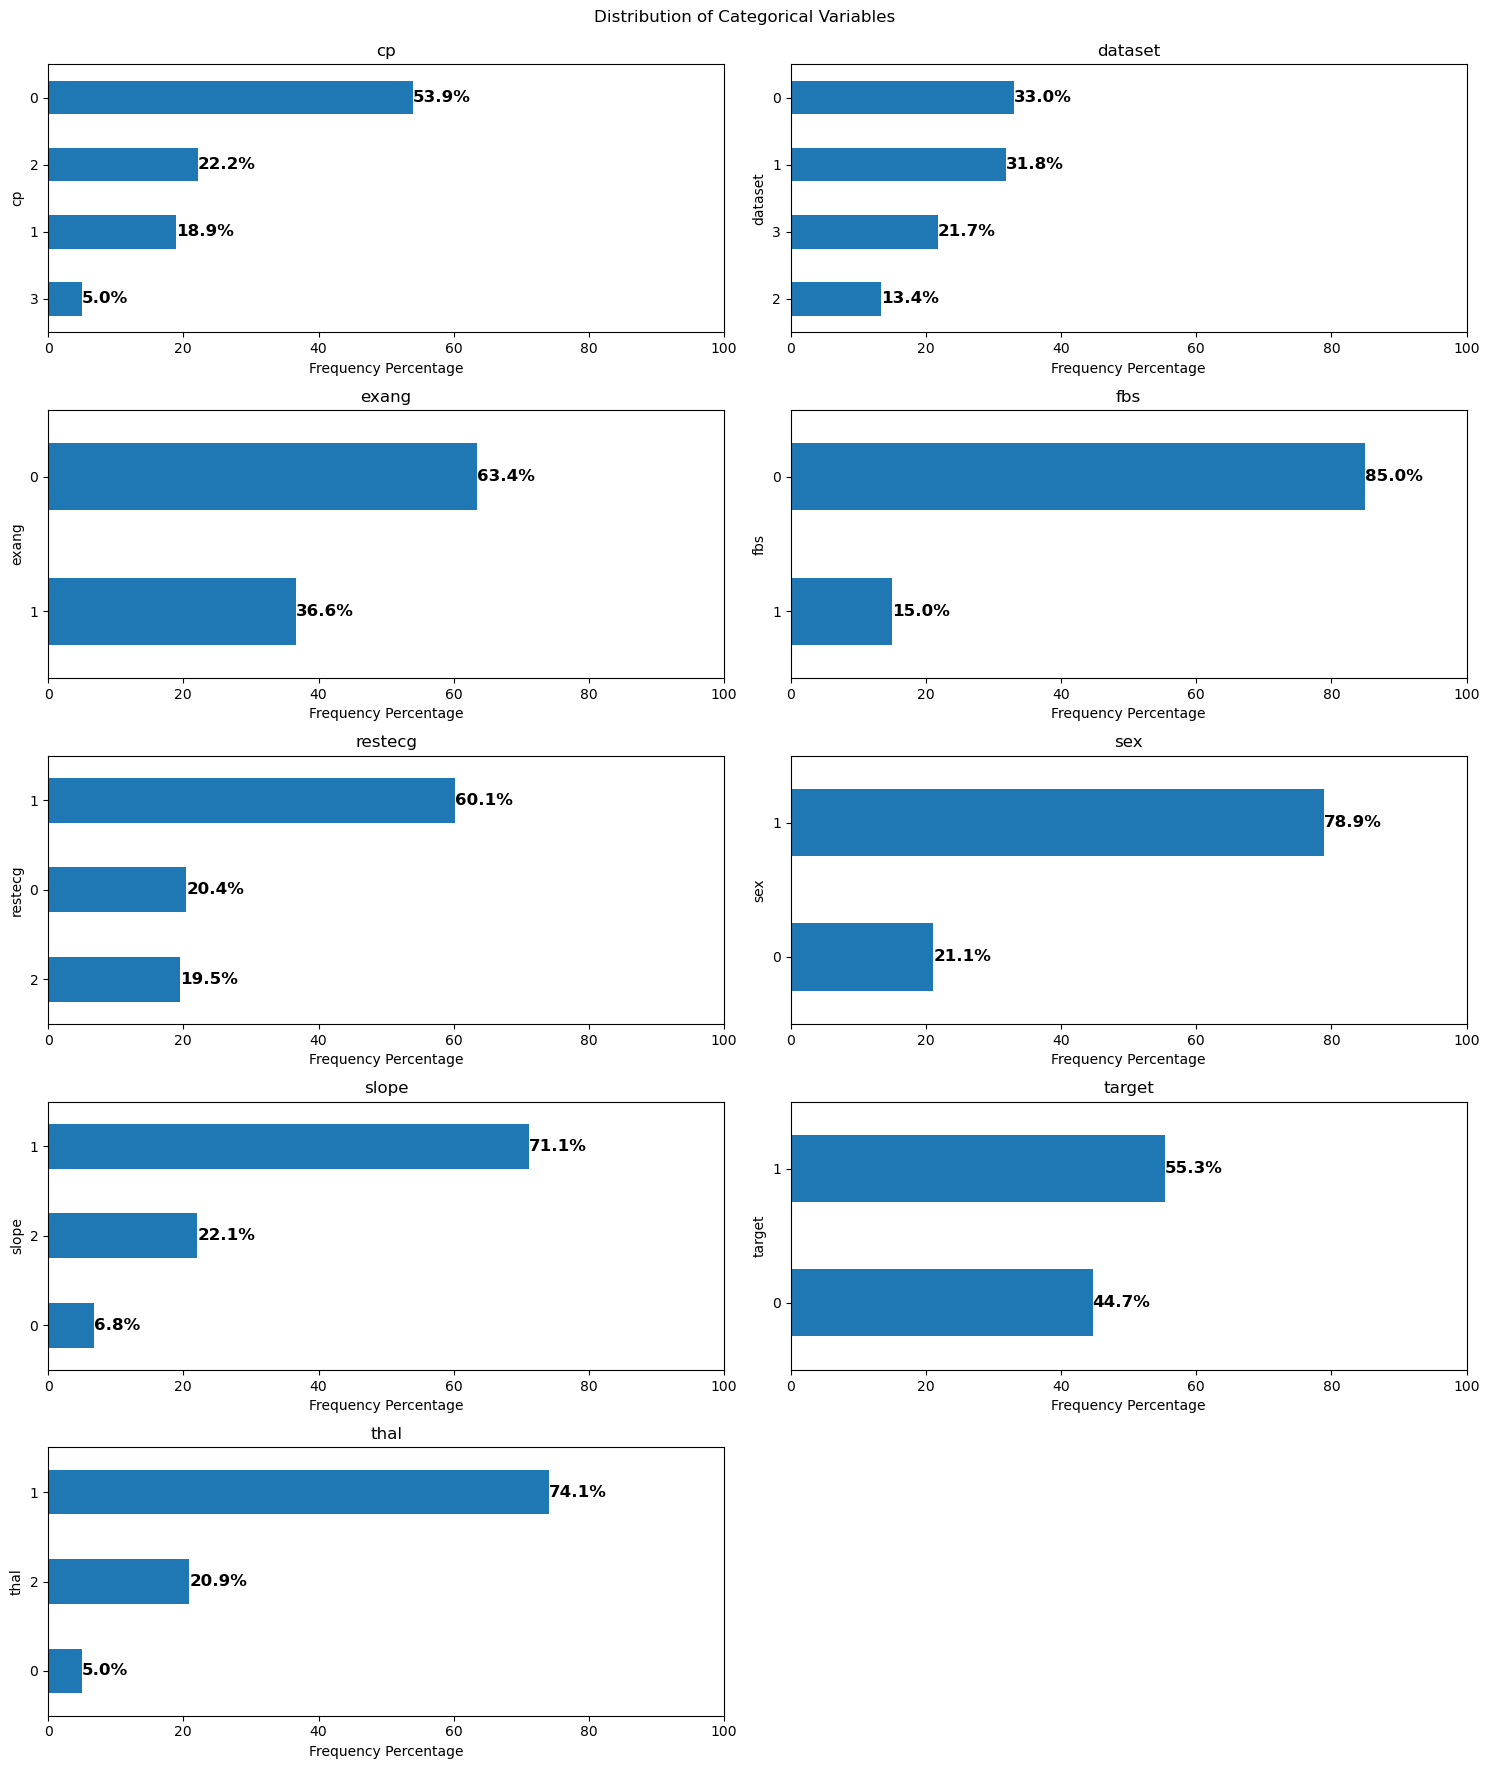

In [15]:
# set up the subplot
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(15,18))

for i, col in enumerate(categorical_feature):
    
    row = i // 2
    col_idx = i % 2

    # calculate frequency percentage
    value_count = df[col].value_counts(normalize=True).mul(100).sort_values()

    # plot barh
    value_count.plot.barh(ax=ax[row, col_idx])

    # Add frequency percentage to the bars
    for index, value in enumerate(value_count):
        ax[row, col_idx].text(value, index, str(round(value,1))+'%', 
                              fontsize=12, weight='bold', va='center')

    ax[row, col_idx].set_xlim([0, 100])
    ax[row, col_idx].set_xlabel("Frequency Percentage")
    ax[row, col_idx].set_title(f'{col}')

ax[4,1].axis('off')

plt.suptitle("Distribution of Categorical Variables")
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

# Data Processing

### Missing value

In [16]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## Treating outliers

In [17]:
continuous_feature

['age', 'trestbps', 'thalch', 'oldpeak', 'ca', 'chol']

In [18]:
Q1 = df[continuous_feature].quantile(0.25)
Q3 = df[continuous_feature].quantile(0.75)
IQR = Q3-Q1
outliers_count_specified = ((df[continuous_feature]<(Q1-1.5*IQR)) | (df[continuous_feature]>(Q3+1.5*IQR))).sum()

outliers_count_specified

age           0
trestbps     28
thalch        2
oldpeak      16
ca          128
chol        185
dtype: int64

In [19]:
# Filter rows without outlires
df_no_outlires =  ((df[continuous_feature]<(Q1-1.5*IQR)) | (df[continuous_feature]>(Q3+1.5*IQR))).any(axis=1)
for col in continuous_feature:
    lower = Q1[col] - 1.5*IQR[col]
    upper = Q3[col] + 1.5*IQR[col]
    df[col] = df[col].apply(lambda x: df[col].median() if x<lower or x>upper else x)

In [20]:
Q1 = df[continuous_feature].quantile(0.25)
Q3 = df[continuous_feature].quantile(0.75)
IQR = Q3-Q1
outliers_count_specified = ((df[continuous_feature]<(Q1-1.5*IQR)) | (df[continuous_feature]>(Q3+1.5*IQR))).sum()

outliers_count_specified

age          0
trestbps     0
thalch       0
oldpeak      0
ca           0
chol        45
dtype: int64

## Categorical Feature Encoding

In [21]:
import pandas as pd

# One-hot encoding
df_encoding = pd.get_dummies(df, columns=['cp', 'restecg', 'thal'], drop_first=True)

# Convert all dummy columns to int (0/1)
dummy_cols = [col for col in df_encoding.columns if 
              any(prefix in col for prefix in ['cp_', 'restecg_', 'thal_'])]

df_encoding[dummy_cols] = df_encoding[dummy_cols].astype(int)

# Convert remaining categorical features
feature_to_convert = ['sex', 'fbs', 'exang', 'slope', 'ca']
for feature in feature_to_convert:
    df_encoding[feature] = df_encoding[feature].astype(int)

# Check data types
print(df_encoding.dtypes)

id             int32
age            int64
sex            int32
dataset        int32
trestbps     float64
chol         float64
fbs            int32
thalch       float64
exang          int32
oldpeak      float64
slope          int32
ca             int32
target         int32
cp_1           int32
cp_2           int32
cp_3           int32
restecg_1      int32
restecg_2      int32
thal_1         int32
thal_2         int32
dtype: object


In [22]:
df_encoding.head()

,id,age,sex,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2
0,0,63,1,0,145.0,233.0,1,150.0,0,2.3,0,0,0,0,0,1,0,0,0,0
1,1,67,1,0,160.0,286.0,0,108.0,1,1.5,1,0,1,0,0,0,0,0,1,0
2,2,67,1,0,120.0,229.0,0,129.0,1,2.6,1,0,1,0,0,0,0,0,0,1
3,3,37,1,0,130.0,250.0,0,187.0,0,3.5,0,0,0,0,1,0,1,0,1,0
4,4,41,0,0,130.0,204.0,0,172.0,0,1.4,2,0,0,1,0,0,0,0,1,0


## Transformaing  Skewed Feature

In [23]:
#Defining the feature x and y 
X = df_encoding.drop('target',axis=1)
Y = df_encoding['target']

In [24]:
# Spliting data into Train and Test dataset
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X,Y,test_size=0.2,random_state=0,stratify=Y)

In [25]:
X_Train.shape,X_Test.shape

((736, 19), (184, 19))

In [26]:
continuous_feature

['age', 'trestbps', 'thalch', 'oldpeak', 'ca', 'chol']

In [27]:
# Adding small constant values to oldpeadk to make all values positive
X_Train['oldpeak'] = X_Train['oldpeak']+0.001
X_Test['oldpeak'] = X_Test['oldpeak']+0.001

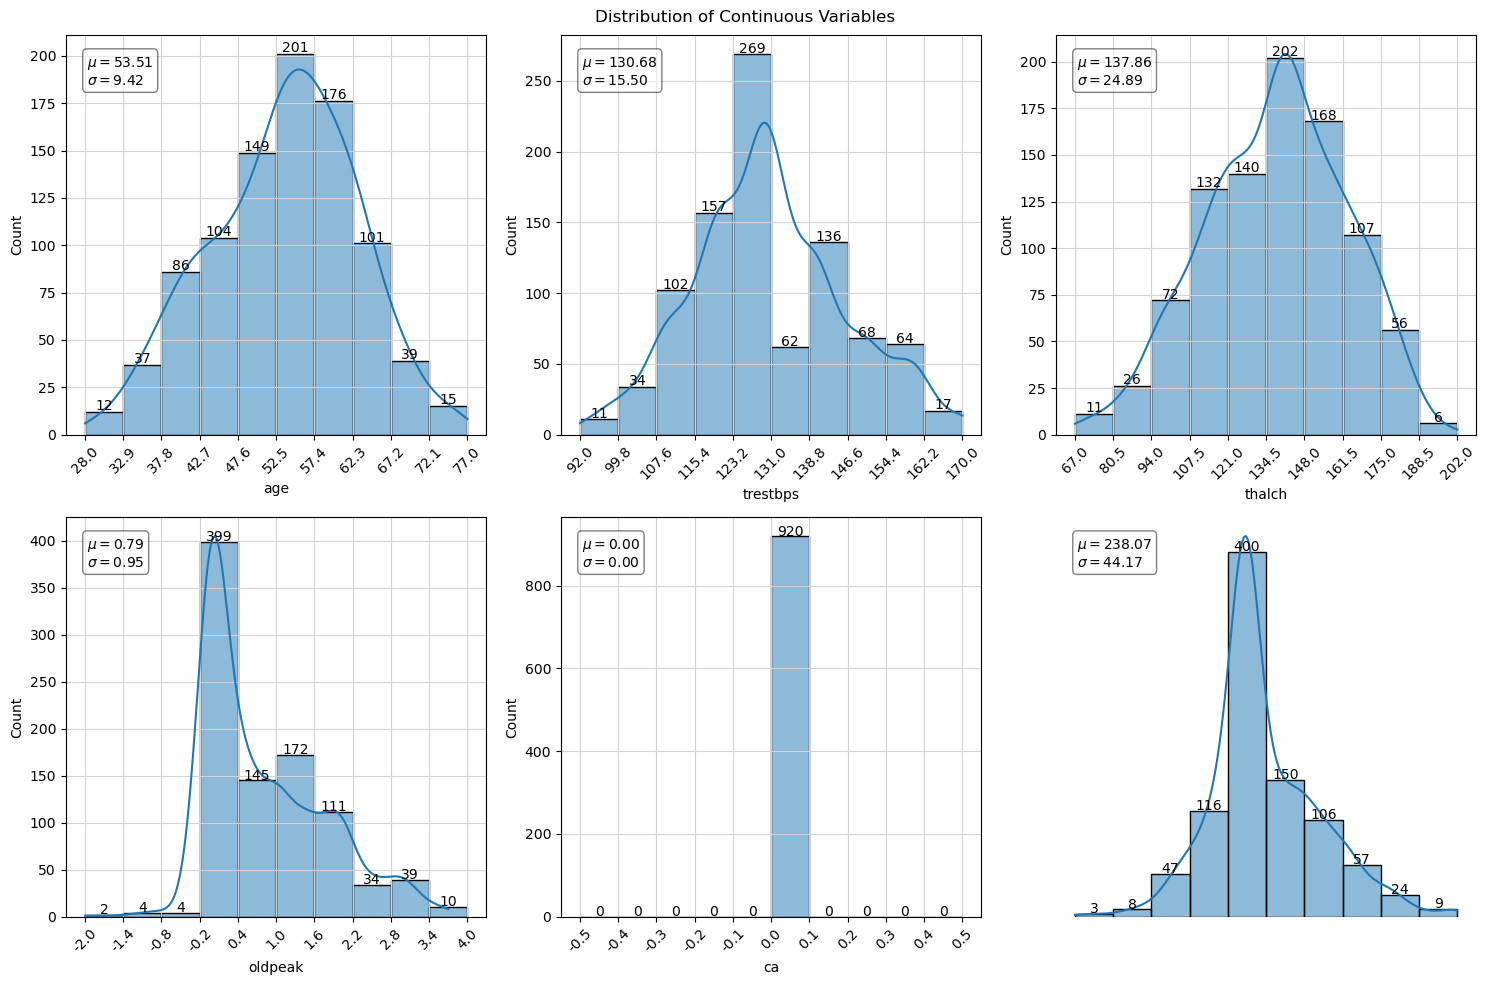

In [28]:
# filter out continuous feature for the univariate analysis
df_continuous = df[continuous_feature]

# set up the subplot
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15,10))

# loop to plot histogram for each continuous feature
for i, col in enumerate(df_continuous):

    x = i // 3
    y = i % 3

    values, bin_edges = np.histogram(
        df_continuous[col],
        range=(np.floor(df_continuous[col].min()),
               np.ceil(df_continuous[col].max()))
    )

    graph = sns.histplot(data=df_continuous, x=col, bins=bin_edges, kde=True, ax=ax[x,y])

    ax[x,y].set_xlabel(col)
    ax[x,y].set_ylabel('Count')

    ax[x,y].set_xticks(np.round(bin_edges,1))
    ax[x,y].set_xticklabels(np.round(bin_edges,1), rotation=45)

    ax[x,y].grid(color='lightgray')

    # annotate bars
    for p in graph.patches:
        ax[x,y].annotate(
            '{}'.format(int(p.get_height())),
            (p.get_x() + p.get_width()/2, p.get_height()+1),
            ha='center',
            fontsize=10
        )

    # mean and std text
    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))

    ax[x,y].text(0.05, 0.95, textstr,
                 transform=ax[x,y].transAxes,
                 fontsize=10,
                 verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax[1,2].axis('off')

plt.suptitle('Distribution of Continuous Variables')
plt.tight_layout()
plt.show()

## Decision Tree Model

In [29]:
# define the base DT model
dt_base = DecisionTreeClassifier(random_state=0)

In [30]:


# DT Hyperparameter tuning
def tune_clf_hyperparameter(clf, param_grid, X_train, y_train, scoring='recall', n_splits=3):

    # Create the cross-validation object
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    
    # Create GridSearchCV object
    clf_grid = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    # Fit the model
    clf_grid.fit(X_train, y_train)
    
    # Get best hyperparameters
    best_hyperparameters = clf_grid.best_params_

    # Return best model and params
    return clf_grid.best_estimator_, best_hyperparameters

In [31]:
# Hyperparameters grod for DT
param_grid_dt={
    'criterion': ['gini','entropy'],
    'max_depth': [2,3],
    'min_samples_split': [2,3,4],
    'min_samples_leaf': [1,2]
}

In [32]:
#calling the function for hyperparameters
best_dt, best_dt_hyperParameter= tune_clf_hyperparameter(dt_base,param_grid_dt,X_Train,Y_Train)

In [33]:
print("DT Optimal Hyperparameters: \n",best_dt_hyperParameter)

DT Optimal Hyperparameters: 
 {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}


## DT Model Evaluation

In [34]:
# Evaluating the optimize model on the train data
print(classification_report(Y_Train, best_dt.predict(X_Train)))

              precision    recall  f1-score   support

           0       0.90      0.76      0.83       329
           1       0.83      0.93      0.88       407

    accuracy                           0.86       736
   macro avg       0.86      0.85      0.85       736
weighted avg       0.86      0.86      0.85       736



In [35]:
# Evaluation optimized model on the test data
print(classification_report(Y_Test,best_dt.predict(X_Test)))

              precision    recall  f1-score   support

           0       0.86      0.72      0.78        82
           1       0.80      0.90      0.85       102

    accuracy                           0.82       184
   macro avg       0.83      0.81      0.81       184
weighted avg       0.82      0.82      0.82       184



In [36]:
def evaluate_model(model,X_Test,Y_Test,model_name):
    ## Eval;uate the performance of a trained model on test data using various metrics.
    # moake predictions
    y_pred = model.predict(X_Test)

    # Get calssification report
    report = classification_report(Y_Test,y_pred,output_dict=True)

    #Evaluate metrices
    metrics={
        'precision_0': report['0']['precision'],
        'precision_1': report['1']['precision'],
        'recall_0': report['0']['recall'],
        'recall_1': report['1']['recall'],
        'f1_0': report['0']['f1-score'],
        'f1_1': report['1']['f1-score'],
        'macro_avg_precision': report['macro avg']['precision'],
        'macro_avg_recall': report['macro avg']['recall'],
        'accuracy': accuracy_score(Y_Test,y_pred)
    }

    # Convert dictionary to dataframe
    df= pd.DataFrame(metrics,index=[model_name]).round(2)

    return df

In [37]:
dt_evaluation = evaluate_model(best_dt,X_Test,Y_Test,'DT')
dt_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,accuracy
DT,0.86,0.8,0.72,0.9,0.78,0.85,0.83,0.81,0.82


## Ramdom Forest Model

In [38]:
# creating object of RF model
rf_base = RandomForestClassifier(random_state=0)

## RF dHyperparameters Tuining

In [39]:
param_grid_rf = {
    'n_estimators': [10, 30, 50, 70, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [True, False]
}


In [40]:

best_rf, best_rf_hyperparams = tune_clf_hyperparameter(
    rf_base, param_grid_rf, X_Train, Y_Train
)

print("RF Optimal Hyperparameters:\n", best_rf_hyperparams)

RF Optimal Hyperparameters:
 {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 30}


## RF Model Evaluation

In [41]:
# Evaluate the optimized model ont he train data
print(classification_report(Y_Train,best_rf.predict(X_Train)))

              precision    recall  f1-score   support

           0       0.91      0.81      0.86       329
           1       0.86      0.94      0.90       407

    accuracy                           0.88       736
   macro avg       0.89      0.88      0.88       736
weighted avg       0.88      0.88      0.88       736



In [42]:
# Evaluate the optimzed model on the test data
print(classification_report(Y_Test,best_rf.predict(X_Test)))

              precision    recall  f1-score   support

           0       0.86      0.77      0.81        82
           1       0.83      0.90      0.86       102

    accuracy                           0.84       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [44]:
rf_evaluation = evaluate_model(best_rf,X_Test,Y_Test,'RF')
rf_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,accuracy
RF,0.86,0.83,0.77,0.9,0.81,0.86,0.85,0.84,0.84


## KNN Model

In [53]:
# Define the base KNN model and set the pipline with scaling
knn_pipline = Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsClassifier())
])

## KNN Hyperparameter Tuning

In [54]:
# Hyperparameter grid for knn
knn_param_grid={
    'knn__n_neighbors': list(range(1,12)),
    'knn__weights': ['uniform','distance'],
    'knn__p': [1,2] # mahattan distance, 2:Euclidean distance
}

In [55]:
best_knn,best_knn_hyperparam = tune_clf_hyperparameter(knn_pipline,knn_param_grid,X_Train,Y_Train)
print("KNN optimal Hyperparameter: \n",best_knn_hyperparam)

KNN optimal Hyperparameter: 
 {'knn__n_neighbors': 9, 'knn__p': 1, 'knn__weights': 'uniform'}


## KNN Model Evaluation

In [56]:
# Evaluate the optimal model on train data
print(classification_report(Y_Train,best_knn.predict(X_Train)))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84       329
           1       0.85      0.91      0.88       407

    accuracy                           0.86       736
   macro avg       0.86      0.86      0.86       736
weighted avg       0.86      0.86      0.86       736



In [57]:
# Evaluating the optimaize model on train data
print(classification_report(Y_Test,best_knn.predict(X_Test)))

              precision    recall  f1-score   support

           0       0.87      0.74      0.80        82
           1       0.82      0.91      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



In [60]:
knn_evaluation = evaluate_model(best_knn,X_Test,Y_Test,'KNN')
knn_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,accuracy
KNN,0.87,0.82,0.74,0.91,0.8,0.86,0.84,0.83,0.84


## SVM MOdel Bulding

### SVM MOdel Defination

In [67]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),   
    ('svm', SVC(probability=True))
])


### SVM Hyperparameter Tuning

In [68]:
param_grid_svm = {
    'svm__C': [0.001, 0.005, 0.05, 0.1, 1, 10, 20],
    'svm__kernel': ['linear', 'rbf', 'poly'],   # fixed spelling
    'svm__gamma': ['scale', 'auto', 0.1, 0.5, 1, 5],
    'svm__degree': [2, 3, 4]
}


In [70]:
best_svm, best_svm_hyperparams = tune_clf_hyperparameter(
    svm_pipeline, param_grid_svm, X_Train, Y_Train
)

print('SVM Optimal Hyperparameters:\n', best_svm_hyperparams)

SVM Optimal Hyperparameters:
 {'svm__C': 0.001, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}


### SVM Model Evaluation

In [72]:
# evaluate the optimized model on train data
print(classification_report(Y_Train,best_svm.predict(X_Train)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       329
           1       0.55      1.00      0.71       407

    accuracy                           0.55       736
   macro avg       0.28      0.50      0.36       736
weighted avg       0.31      0.55      0.39       736



C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [73]:
# evaluate the optimized model on th etest data
print(classification_report(Y_Test,best_svm.predict(X_Test)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        82
           1       0.55      1.00      0.71       102

    accuracy                           0.55       184
   macro avg       0.28      0.50      0.36       184
weighted avg       0.31      0.55      0.40       184



C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [74]:
svm_evaluation = evaluate_model(best_svm,X_Test,Y_Test,'SVM')
svm_evaluation

C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,accuracy
SVM,0.0,0.55,0.0,1.0,0.0,0.71,0.28,0.5,0.55


## Conclusion

In [76]:
# Crncatenate the dataframe
all_evaluation = [dt_evaluation,rf_evaluation,knn_evaluation,svm_evaluation]
result = pd.concat(all_evaluation)

# sort by recall_1
result = result.sort_values(by='recall_1',ascending=False).round(2)
result

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,accuracy
SVM,0.00,0.55,0.00,1.00,0.00,0.71,0.28,0.50,0.55
KNN,0.87,0.82,0.74,0.91,0.80,0.86,0.84,0.83,0.84
DT,0.86,0.80,0.72,0.90,0.78,0.85,0.83,0.81,0.82
RF,0.86,0.83,0.77,0.90,0.81,0.86,0.85,0.84,0.84


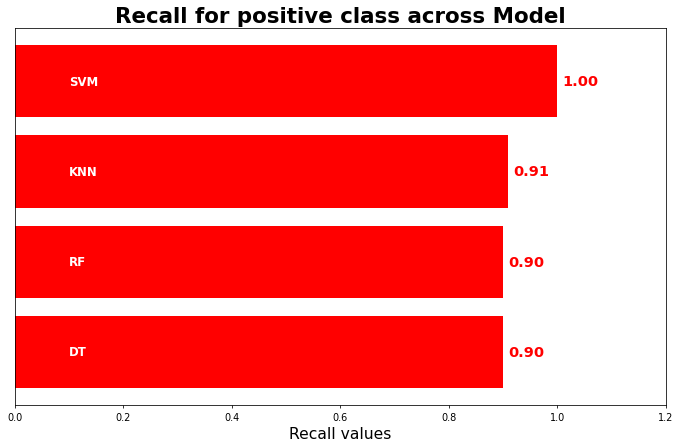

In [78]:
# sort values based on recall_1
result.sort_values(by='recall_1', ascending=True, inplace=True)

recall_1_scores = result['recall_1']

# plot the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7), dpi=70)

ax.barh(result.index, recall_1_scores, color='red')

# Annotation the values and index
for i, (value, name) in enumerate(zip(recall_1_scores, result.index)):
    ax.text(value + 0.01, i, f"{value:.2f}",
            ha='left', va='center',
            fontweight='bold', color='red', fontsize=15)

    ax.text(0.1, i, name,
            ha='left', va='center',
            fontweight='bold', color='white', fontsize=12)

# remove yticks
ax.set_yticks([])

# set x-axis limit
ax.set_xlim([0, 1.2])

# add title and labels
plt.title('Recall for positive class across Model', fontweight='bold', fontsize=22)
plt.xlabel('Recall values', fontsize=16)

plt.show()

 The SVM model demonstrate a commendable capabilities in recognizing potential heart patients
 with a recall of 1 for class 1 it's evident that almost all petient with heart disease are coreectly identified

 This is of paramount importance in a medical setting. However th model's balanced performance ensure rtha while aiming for high recall. It doesnot 
 cmpromise on precision thereby not overburdening the system with unnecessary alerts